# Aadhaar Digital Infrastructure: Policy Insights & Maturity Assessment

## Executive Summary

This document presents a data-driven analysis of **Aadhaar enrolment and update patterns** across India's districts from March 2025 to December 2025 (9 months). By examining operational metrics—enrolments, demographic updates, and biometric updates—we identify **systemic patterns** that reveal the digital maturity and service delivery capacity of Aadhaar infrastructure nationwide.

### Policy Objectives Addressed
1. **Infrastructure Utilization**: Identify underutilized or dormant enrolment centers
2. **Service Quality**: Detect districts with high correction loads indicating enrolment quality issues
3. **Child Welfare Compliance**: Monitor mandatory biometric update compliance for children aged 5–17
4. **Hardware & Process Health**: Flag districts showing signs of biometric capture degradation
5. **Resource Allocation**: Provide evidence-based recommendations for staffing and capacity planning

### Key Metrics Framework

| Metric | Formula | Policy Signal |
|--------|---------|---------------|
| **Update-to-Enrolment Ratio** | Updates / (Enrolments + 1) | Operational load vs. expansion |
| **Update Dependency Ratio** | Updates / Total Activity | Enrolment quality indicator |
| **Dormancy Index** | % months with zero activity | Infrastructure accessibility |
| **Biometric Decay Score (BDS)** | Adult Bio Updates / Total Adult Updates | Hardware/capture quality |
| **Child Compliance Index (CCI)** | Child Bio Updates (5–17) / Total Child Activity | Mandatory update compliance |

### Digital Maturity Clusters Identified

Through unsupervised machine learning (K-Means clustering), districts were classified into **four maturity archetypes**:

| Cluster | Label | Districts Profile |
|---------|-------|-------------------|
| **0** | Stable Mature (Maintenance Mode) | High activity, high updates, consistent operations |
| **1** | Emerging / Expansion Phase | Growing enrolment base, moderate corrections |
| **2** | Dormant / Low Access | Minimal activity, potential accessibility barriers |
| **3** | High-Stress / Legacy Correction | Extreme update loads, legacy data quality issues |

---

## Data Preparation & Environment Setup

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
digital_maturity_df = pd.read_csv("data/digital_maturity_df.csv")

In [3]:
district_gdf = gpd.read_file("data/india_district.geojson")

In [4]:
digital_maturity_df.head()

,state,district,mean_update_to_enrolment_ratio,mean_update_dependency,update_to_enrolment_ratio_volatility,dependency_volatility,pct_active_months,activity_growth_slope,maturity_cluster,mean_monthly_activity
0,ANDAMAN & NICOBAR ISLANDS,ANDAMANS,106.583631,0.879568,97.416098,0.309773,0.9,42.703030,0,284.0
1,ANDAMAN & NICOBAR ISLANDS,NICOBARS,0.550000,0.163333,1.257201,0.285644,0.3,0.260606,1,0.7
2,ANDAMAN & NICOBAR ISLANDS,SOUTH ANDAMAN,6.728472,0.376071,9.163387,0.485612,0.4,26.375758,1,71.0
3,ANDAMAN AND NICOBAR ISLANDS,NICOBAR,149.532449,0.873744,207.028878,0.308890,0.9,-9.145455,0,267.3
4,ANDAMAN AND NICOBAR ISLANDS,NORTH AND MIDDLE ANDAMAN,501.677162,0.884397,563.351927,0.311274,0.9,-12.933333,0,852.4


In [5]:
cluster_name_map = {
    0: "Stable Mature (Maintenance Mode)",
    1: "Emerging / Expansion Phase",
    2: "Dormant / Low Access",
    3: "High-Stress / Legacy Correction"
}

digital_maturity_df["maturity_label"] = (
    digital_maturity_df["maturity_cluster"]
    .map(cluster_name_map)
)


---

## 1. Digital Maturity Gradient: Geographic Distribution

### Policy Context
Understanding the **geographic distribution of digital maturity** is critical for:
- Targeted resource allocation and staffing decisions
- Identifying regional disparities in service delivery capacity
- Planning mobile enrolment drives in underserved areas
- Prioritizing hardware upgrades and training interventions

### Cluster Interpretation Guide

Based on the clustering analysis, each maturity tier exhibits distinct operational signatures:

| Cluster | Update:Enrolment Ratio | Update Dependency | Active Months | Growth Trajectory |
|---------|------------------------|-------------------|---------------|-------------------|
| **Stable Mature** | ~2,585 | 85% | 90% | +151/month |
| **Emerging/Expansion** | ~12.7 | 35% | 42% | +29/month |
| **Dormant/Low Access** | ~0.1 | 4% | 16% | −12/month |
| **High-Stress/Legacy** | ~11,071 | 87% | 90% | +1,028/month |

### What This Map Reveals
The choropleth map below displays each district colored by its maturity cluster. This visualization enables policymakers to:
- Identify **regional patterns** (e.g., clusters of dormant districts)
- Spot **state-level disparities** in infrastructure maturity
- Plan **inter-district resource sharing** strategies

In [6]:
digital_maturity_df.head()

,state,district,mean_update_to_enrolment_ratio,mean_update_dependency,update_to_enrolment_ratio_volatility,dependency_volatility,pct_active_months,activity_growth_slope,maturity_cluster,mean_monthly_activity,maturity_label
0,ANDAMAN & NICOBAR ISLANDS,ANDAMANS,106.583631,0.879568,97.416098,0.309773,0.9,42.703030,0,284.0,Stable Mature (Maintenance Mode)
1,ANDAMAN & NICOBAR ISLANDS,NICOBARS,0.550000,0.163333,1.257201,0.285644,0.3,0.260606,1,0.7,Emerging / Expansion Phase
2,ANDAMAN & NICOBAR ISLANDS,SOUTH ANDAMAN,6.728472,0.376071,9.163387,0.485612,0.4,26.375758,1,71.0,Emerging / Expansion Phase
3,ANDAMAN AND NICOBAR ISLANDS,NICOBAR,149.532449,0.873744,207.028878,0.308890,0.9,-9.145455,0,267.3,Stable Mature (Maintenance Mode)
4,ANDAMAN AND NICOBAR ISLANDS,NORTH AND MIDDLE ANDAMAN,501.677162,0.884397,563.351927,0.311274,0.9,-12.933333,0,852.4,Stable Mature (Maintenance Mode)


In [7]:
# Standardize district_gdf
district_gdf["state"] = (
    district_gdf["NAME_1"]
    .str.upper()
    .str.strip()
)

district_gdf["district"] = (
    district_gdf["NAME_2"]
    .str.upper()
    .str.strip()
)

# Standardize digital_maturity_df
digital_maturity_df["state"] = (
    digital_maturity_df["state"]
    .str.upper()
    .str.strip()
)

digital_maturity_df["district"] = (
    digital_maturity_df["district"]
    .str.upper()
    .str.strip()
)


In [8]:
district_gdf.head(1)

,ID_0,ISO,NAME_0,ID_1,NAME_1,ID_2,NAME_2,NL_NAME_2,VARNAME_2,TYPE_2,ENGTYPE_2,geometry,state,district
0,105,IND,India,1,Andaman and Nicobar,1,Andaman Islands,None,None,District,District,"MULTIPOLYGON (((92.51583 10.89764, 92.51611 10...",ANDAMAN AND NICOBAR,ANDAMAN ISLANDS


In [9]:
map_df = district_gdf.merge(
    digital_maturity_df[
        ["state", "district", "maturity_label"]
    ],
    on=["state", "district"],
    how="left"
)


In [10]:
from matplotlib.colors import ListedColormap


In [11]:
maturity_colors = {
    "Dormant / Low Access": "#d9d9d9",          # light gray
    "Emerging / Expansion Phase": "#fdae61",                 # amber
    "Stable Mature (Maintenance Mode)": "#abdda4",  # muted green
    "High-Stress / Legacy Correction": "#2b83ba"       # deep blue
}

In [12]:
maturity_order = [
    "Dormant / Low Access",
    "Emerging / Expansion Phase",
    "Stable Mature (Maintenance Mode)",
    "High-Stress / Legacy Correction"
]


maturity_cmap = ListedColormap(
    [maturity_colors[label] for label in maturity_order]
)

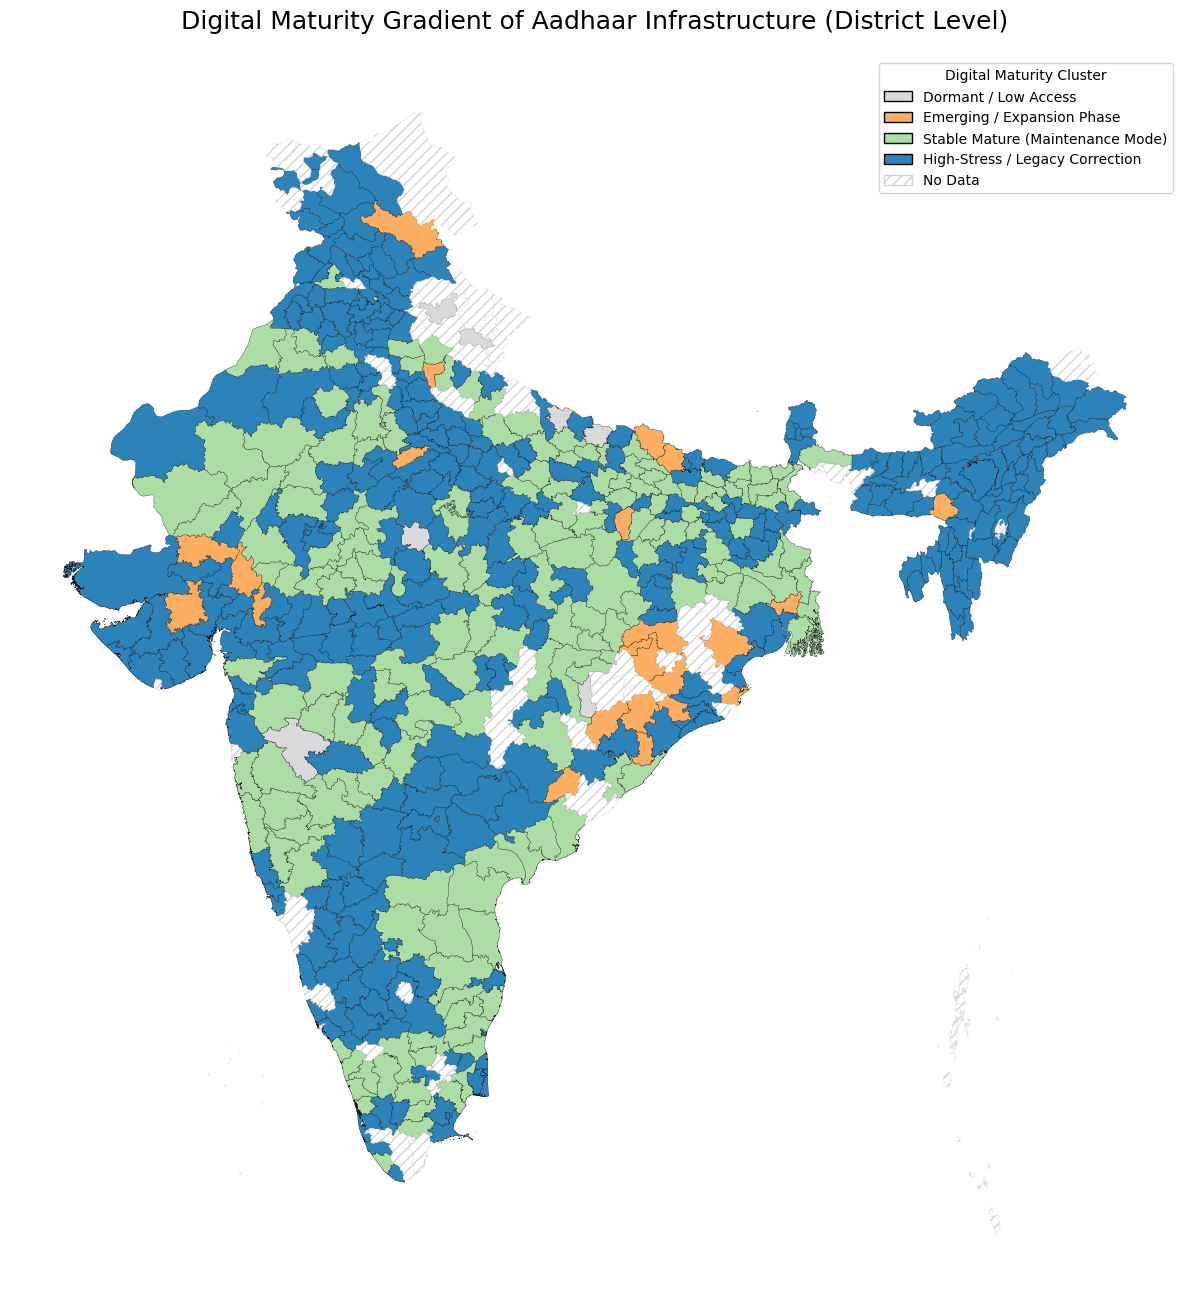

In [13]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(1, 1, figsize=(12, 14))

map_df.plot(
    column="maturity_label",
    categorical=True,
    legend=False,
    cmap=maturity_cmap,
    linewidth=0.2,
    edgecolor="black",
    ax=ax,
    missing_kwds={
        "color": "white",
        "edgecolor": "lightgrey",
        "hatch": "///",
        "label": "No Data"
    }
)

# Create custom legend with hatch pattern for "No Data"
legend_handles = [
    Patch(facecolor=maturity_colors[label], edgecolor='black', label=label)
    for label in maturity_order
]

# Add "No Data" entry with hatch pattern
legend_handles.append(
    Patch(facecolor='white', edgecolor='lightgrey', hatch='///', label='No Data')
)

ax.legend(
    handles=legend_handles,
    title="Digital Maturity Cluster",
    loc="best",
    frameon=True
)

ax.set_title(
    "Digital Maturity Gradient of Aadhaar Infrastructure (District Level)",
    fontsize=18,
    pad=20
)

ax.axis("off")

plt.tight_layout()
plt.show()

---

## 2. Digital Maturity × Activity Volume: Bivariate Analysis

### Policy Context
Maturity classification alone does not capture **operational scale**. A "Stable Mature" district processing 50 transactions/month differs fundamentally from one processing 50,000. This bivariate visualization combines:
- **Maturity Cluster** (color) — operational health profile
- **Mean Monthly Activity** (bubble size) — transaction volume

### Why This Matters for Resource Planning
| Scenario | Implication | Action Required |
|----------|-------------|-----------------|
| High maturity + High volume | Well-functioning, high-capacity centers | Maintain; use as training models |
| High maturity + Low volume | Efficient but underutilized | Investigate demand-side barriers |
| Low maturity + High volume | Overburdened, quality at risk | Urgent capacity expansion |
| Low maturity + Low volume | Underserved populations | Mobile camps, awareness drives |

### What This Map Reveals
The overlay of activity bubbles on maturity clusters enables identification of:
- **High-volume stress points** requiring immediate intervention
- **Silent districts** with adequate infrastructure but minimal usage
- **Success stories** that can serve as operational benchmarks

In [14]:
map_df = map_df.merge(
    digital_maturity_df[
        ["state", "district", "mean_monthly_activity"]
    ],
    on=["state", "district"],
    how="left"
)


In [15]:
import numpy as np

# Replace NaN with 0 for plotting
map_df["mean_monthly_activity"] = map_df["mean_monthly_activity"].fillna(0)

# Create a scaled size for plotting
map_df["activity_size"] = np.sqrt(map_df["mean_monthly_activity"])


In [16]:
activity_quantiles = map_df["mean_monthly_activity"].quantile([0.25, 0.5, 0.75]).round(0)
activity_quantiles


0.25     1983.0
0.50    12173.0
0.75    22948.0
Name: mean_monthly_activity, dtype: float64

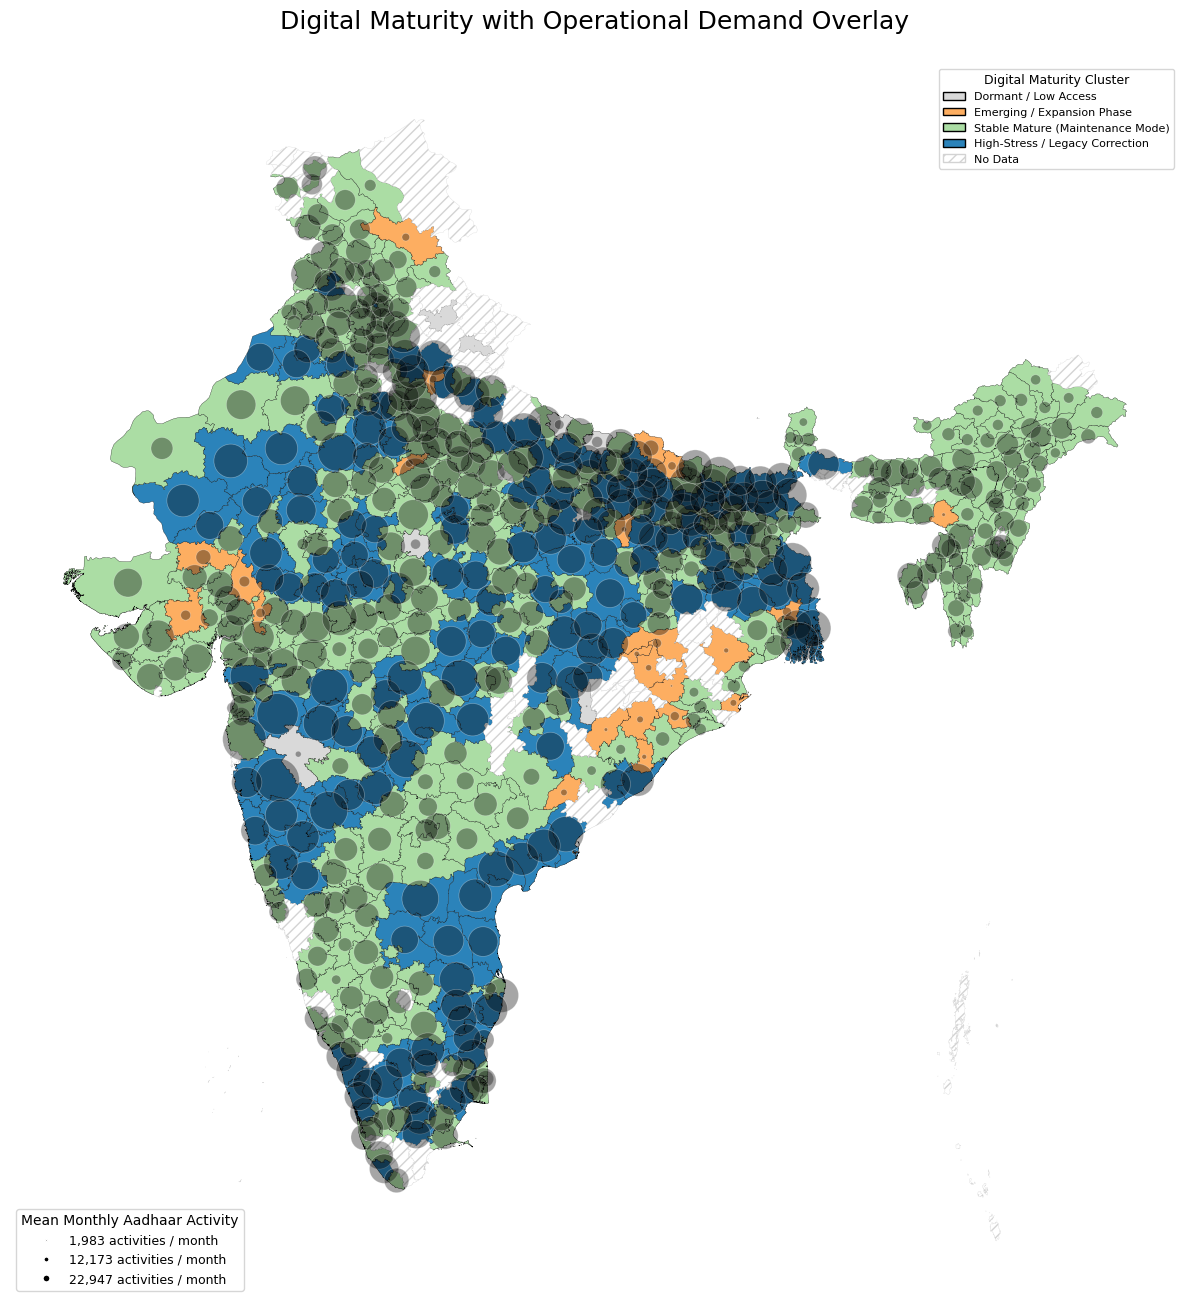

In [17]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

fig, ax = plt.subplots(1, 1, figsize=(12, 14))

# Base maturity map
map_df.plot(
    column="maturity_label",
    categorical=True,
    categories=maturity_order,
    cmap=maturity_cmap,
    linewidth=0.2,
    edgecolor="black",
    ax=ax,
    legend=False,
    missing_kwds={
        "color": "white",
        "edgecolor": "lightgrey",
        "hatch": "///",
        "label": "No Data"
    }
)

# Overlay activity circles at district centroids
activity_df = map_df[map_df["mean_monthly_activity"] > 0].copy()

# Project to a suitable CRS for India (Asia South Albers Equal Area Conic)
activity_df_projected = activity_df.to_crs("EPSG:24378")
activity_df["centroid"] = activity_df_projected.geometry.centroid.to_crs(map_df.crs)

ax.scatter(
    x=activity_df["centroid"].x,
    y=activity_df["centroid"].y,
    s=activity_df["activity_size"] * 3,  # Scale factor for visibility
    color="black",
    alpha=0.35,
    linewidth=0.5,
    edgecolor="white"
)

# Title + subtitle
ax.set_title(
    "Digital Maturity with Operational Demand Overlay",
    fontsize=18,
    pad=25
)

# Create size legend with reasonable marker sizes
activity_quantiles = map_df["mean_monthly_activity"].quantile([0.25, 0.5, 0.75])

legend_handles = [
    Line2D(
        [0], [0],
        marker="o",
        color="none",
        label=f"{int(val):,} activities / month",
        markerfacecolor="black",
        markeredgecolor="white",
        markersize=np.sqrt(val) / 30  # Scale down for legend
    )
    for val in activity_quantiles
]

size_legend = ax.legend(
    handles=legend_handles,
    title="Mean Monthly Aadhaar Activity",
    loc="lower left",
    frameon=True,
    fontsize=9
)

# Add maturity color legend
maturity_legend_handles = [
    Patch(facecolor=maturity_colors[label], edgecolor='black', label=label)
    for label in maturity_order
]

# Add "No Data" entry with hatch pattern
maturity_legend_handles.append(
    Patch(facecolor='white', edgecolor='lightgrey', hatch='///', label='No Data')
)

ax.legend(
    handles=maturity_legend_handles,
    title="Digital Maturity Cluster",
    loc="upper right",
    frameon=True,
    fontsize=8,
    title_fontsize=9
)

# Add back the size legend
ax.add_artist(size_legend)

ax.axis("off")
plt.tight_layout()
plt.show()

---

## 3. Expansion vs. Correction: Operational Mode Analysis

### Policy Context
Every Aadhaar transaction falls into one of two categories:
- **Expansion activities**: New enrolments (first-time Aadhaar generation)
- **Correction activities**: Demographic or biometric updates (fixing/updating existing records)

The balance between these activities reveals whether a district's infrastructure is in **growth mode** (adding new beneficiaries) or **maintenance mode** (correcting legacy records).

### Interpreting the Quadrants

| Quadrant | Profile | Policy Interpretation |
|----------|---------|----------------------|
| **Top-Right** | High enrolment + High updates | High-activity districts, fully operational |
| **Top-Left** | Low enrolment + High updates | Correction-heavy; possible data quality issues at enrolment |
| **Bottom-Right** | High enrolment + Low updates | Expansion-focused; new coverage areas |
| **Bottom-Left** | Low enrolment + Low updates | Dormant or low-demand regions |

### What This Scatter Plot Reveals
By plotting total enrolments against total updates (colored by maturity cluster), we can:
- Identify districts stuck in **perpetual correction cycles**
- Spot **expansion frontiers** where new populations are being enrolled
- Detect **balanced operations** vs. **skewed workloads**

### Actionable Recommendations
- **Top-Left quadrant districts**: Audit enrolment quality processes; improve operator training
- **Bottom-Left quadrant districts**: Deploy mobile enrolment camps; community awareness programs
- **Cluster 3 (High-Stress)**: Allocate additional operators; consider data cleanup initiatives

In [18]:
scatter_df = digital_maturity_df[
    ["mean_monthly_activity", "mean_update_to_enrolment_ratio", "maturity_label", "district"]
].dropna()

In [19]:
cluster_colors = {
    "Dormant / Low Access": "#d9d9d9",
    "Emerging / Expansion Phase": "#fdae61",
    "Stable Mature (Maintenance Mode)": "#abdda4",
    "High-Stress / Legacy Correction": "#2b83ba"
}

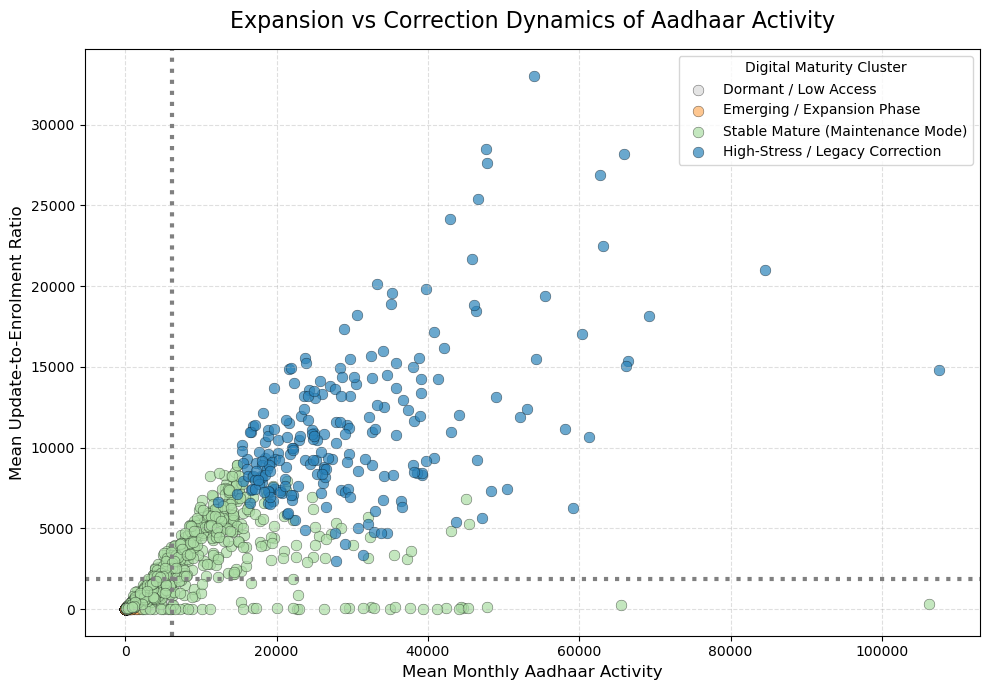

In [20]:
fig, ax = plt.subplots(figsize=(10, 7))

for cluster, color in cluster_colors.items():
    subset = scatter_df[scatter_df["maturity_label"] == cluster]
    
    ax.scatter(
        subset["mean_monthly_activity"],
        subset["mean_update_to_enrolment_ratio"],
        label=cluster,
        color=color,
        alpha=0.7,
        edgecolor="black",
        linewidth=0.3,
        s=60
    )

ax.set_title(
    "Expansion vs Correction Dynamics of Aadhaar Activity",
    fontsize=16,
    pad=15
)

ax.set_xlabel("Mean Monthly Aadhaar Activity", fontsize=12)
ax.set_ylabel("Mean Update-to-Enrolment Ratio", fontsize=12)

ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(title="Digital Maturity Cluster", frameon=True)

ax.axvline(
    scatter_df["mean_monthly_activity"].median(),
    color="grey",
    linestyle=":",
    linewidth=3
)

ax.axhline(
    scatter_df["mean_update_to_enrolment_ratio"].median(),
    color="grey",
    linestyle=":",
    linewidth=3
)


plt.tight_layout()
plt.show()

---

## 4. Biometric Decay Score (BDS) & Child Compliance Index (CCI)

### Policy Context

#### Biometric Decay Score (BDS)
The BDS measures the proportion of **adult biometric updates** relative to total adult activity:

$$\text{BDS} = \frac{\text{Adult Biometric Updates}}{\text{Total Adult Updates}}$$

**High BDS signals**:
- Fingerprint/iris capture degradation over time
- Hardware quality issues at enrolment centers
- Environmental factors affecting biometric templates
- Need for biometric modality review or hardware refresh

#### Child Compliance Index (CCI)
UIDAI mandates biometric updates for children at ages **5 and 15 years** as their biometrics mature. The CCI tracks compliance:

$$\text{CCI} = \frac{\text{Child Biometric Updates (5–17)}}{\text{Total Child Activity}}$$

**Low CCI signals**:
- Awareness gaps among parents/guardians
- School-Aadhaar linkage program gaps
- Access barriers for child populations
- Need for targeted outreach campaigns

### What These Charts Reveal

| Chart | Insight |
|-------|---------|
| **Top BDS Districts** | Hardware/process issues requiring urgent attention |
| **Bottom CCI Districts** | Child welfare compliance gaps; outreach priority areas |

### Actionable Recommendations

| Finding | Recommended Action |
|---------|-------------------|
| High BDS (>0.7) | Audit biometric devices; schedule hardware refresh; operator retraining |
| Low CCI (<0.3) | Partner with schools for update camps; SMS/IVR reminders to parents |
| Both high BDS + low CCI | Priority intervention districts requiring multi-pronged approach |

In [21]:
monthly_base = pd.read_csv("data/monthly_metrics.csv")

In [22]:
dormancy_index = (
    monthly_base
    .groupby(["state", "district"], as_index=False)
    .agg(
        dormancy_index=("is_active", lambda x: 1 - x.mean())
    )
)

In [23]:
top_dormant = (
    dormancy_index
    .sort_values("dormancy_index", ascending=False)
    .head(30)
    [["state", "district"]]
)


In [24]:
heatmap_base = monthly_base.merge(top_dormant, on=["state", "district"], how="inner")

# Create combined label
heatmap_base["district_label"] = heatmap_base["state"] + " (" + heatmap_base["district"] + ")"

heatmap_df = (
    heatmap_base
    .pivot_table(
        index="district_label",
        columns="month",
        values="is_active",
        fill_value=0
    )
)

In [25]:
heatmap_df = heatmap_df.sort_index(axis=1)

/tmp/ipykernel_95059/1577510314.py:51: UserWarning: Glyph 136 (\x88) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_95059/1577510314.py:51: UserWarning: Glyph 146 (\x92) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/dhiran/miniconda3/envs/ml_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 136 (\x88) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dhiran/miniconda3/envs/ml_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 146 (\x92) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


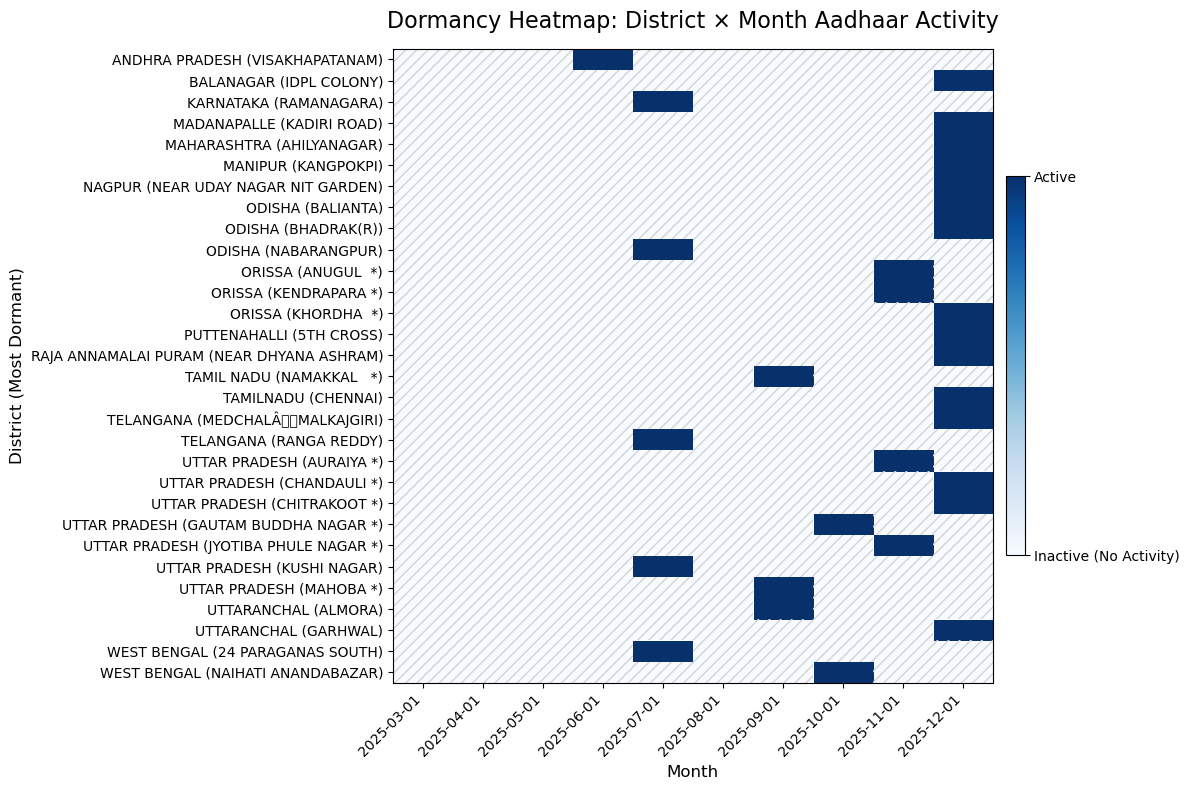

In [26]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(12, 8))

im = ax.imshow(
    heatmap_df.values,
    aspect="auto",
    cmap="Blues",
    interpolation="nearest"
)

# Add hatching to inactive cells (value = 0)
for i in range(heatmap_df.shape[0]):
    for j in range(heatmap_df.shape[1]):
        if heatmap_df.values[i, j] == 0:
            ax.add_patch(
                mpatches.Rectangle(
                    (j - 0.5, i - 0.5), 1, 1,
                    fill=False,
                    edgecolor='lightgrey',
                    hatch='///',
                    linewidth=0
                )
            )

ax.set_title(
    "Dormancy Heatmap: District × Month Aadhaar Activity",
    fontsize=16,
    pad=15
)

ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("District (Most Dormant)", fontsize=12)

ax.set_xticks(range(len(heatmap_df.columns)))
ax.set_xticklabels(
    heatmap_df.columns.astype(str),
    rotation=45,
    ha="right"
)

ax.set_yticks(range(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index)

# Binary colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(["Inactive (No Activity)", "Active"])

plt.tight_layout()
plt.show()

---

## 5. Dormancy & Stress Patterns: Temporal Heatmap Analysis

### Policy Context
Infrastructure dormancy—periods of zero recorded activity—indicates:
- **Access barriers**: Geographic, economic, or awareness-related obstacles
- **Operational failures**: Non-functional centers, staffing gaps
- **Seasonal patterns**: Agricultural cycles, migration, weather impacts

Conversely, **operational stress** (extreme update-to-enrolment ratios) indicates:
- Data quality issues inherited from past enrolments
- Insufficient capacity to handle correction backlog
- Process inefficiencies requiring systemic intervention

### The Dormancy-Stress Matrix

| Dormancy | Stress | Interpretation |
|----------|--------|----------------|
| Low | Low | Healthy, balanced operations |
| Low | High | Active but overburdened; quality issues |
| High | Low | Underutilized infrastructure; demand gap |
| High | High | Critical: Sporadic activity with poor quality |

### What This Heatmap Reveals
The heatmap displays the **top dormant districts** alongside their stress profiles, enabling:
- Identification of **persistently inactive** regions
- Detection of **stress spikes** during active periods
- Discovery of **seasonal dormancy** patterns

### Actionable Recommendations

| Pattern Observed | Policy Response |
|-----------------|-----------------|
| Consecutive dormant months | Deploy mobile enrolment units; investigate center functionality |
| High dormancy + high stress | Systemic quality issues; comprehensive process audit needed |
| Seasonal dormancy spikes | Schedule outreach aligned with agricultural/migration calendars |
| State-wide dormancy clusters | Escalate to state UIDAI office; review regional infrastructure strategy |

In [27]:
bds_summary = pd.read_csv("data/district_summary/district_bds_summary.csv")
cci_summary = pd.read_csv("data/district_summary/district_cci_summary.csv")

In [28]:
top_bds = (
    bds_summary
    .sort_values("mean_bds", ascending=False)
    .head(10)
)

bottom_cci = (
    cci_summary
    .sort_values("mean_cci", ascending=True)
    .head(10)
)


In [29]:
cluster_info = digital_maturity_df[
    ["state", "district", "maturity_label"]
]

top_bds = top_bds.merge(
    cluster_info, on=["state", "district"], how="left"
)

bottom_cci = bottom_cci.merge(
    cluster_info, on=["state", "district"], how="left"
)

# Create district labels with state
top_bds["district_label"] = top_bds["state"] + " (" + top_bds["district"] + ")"
bottom_cci["district_label"] = bottom_cci["state"] + " (" + bottom_cci["district"] + ")"

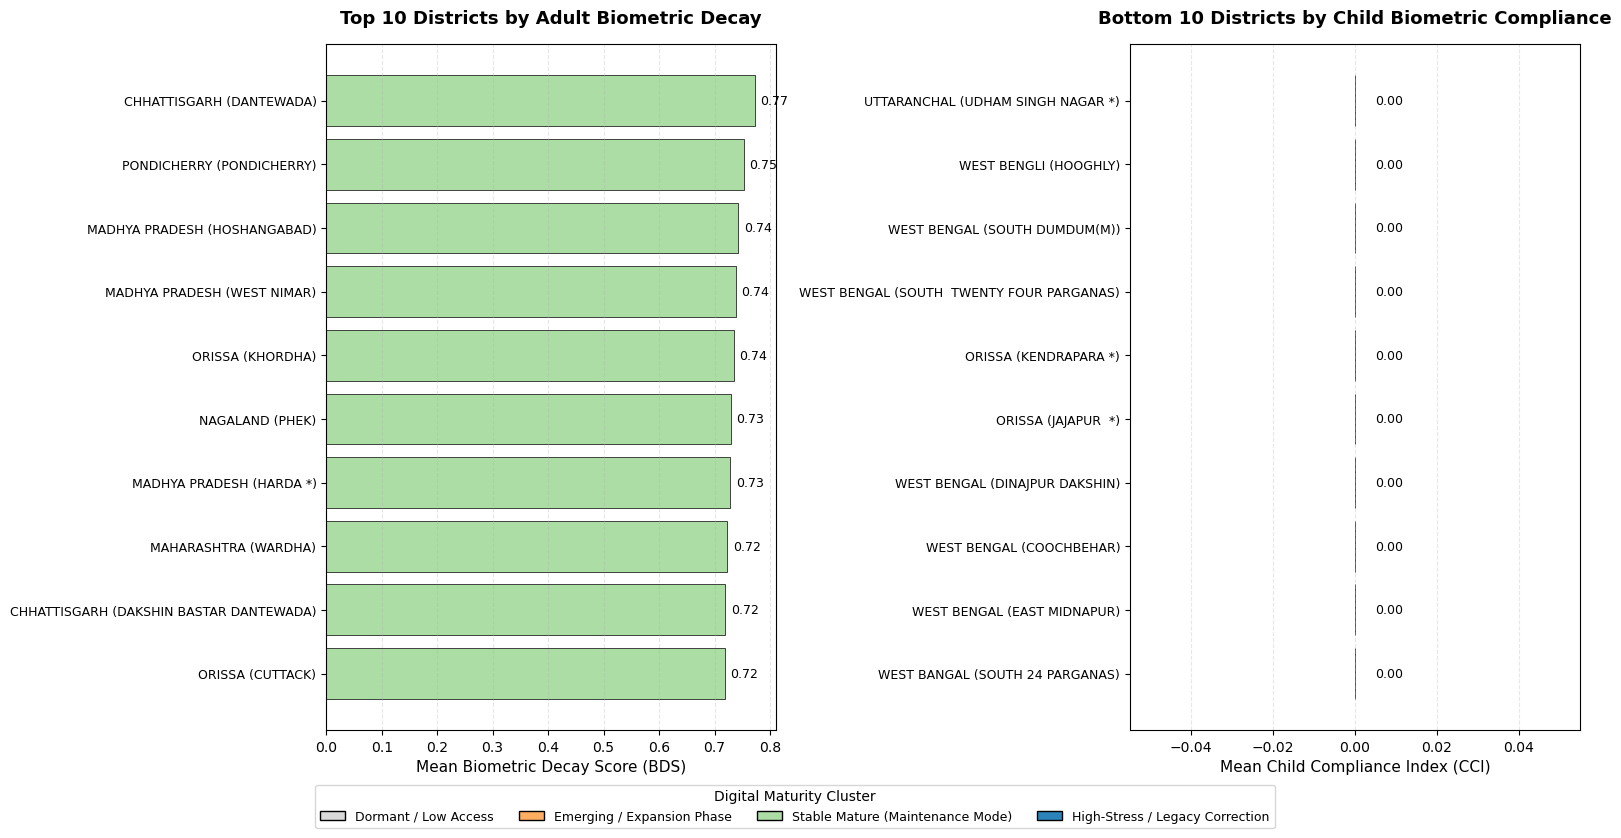

In [30]:
from matplotlib.patches import Patch

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# BDS Bar Chart (left)
colors_bds = [maturity_colors.get(label, "#cccccc") for label in top_bds["maturity_label"]]

ax1.barh(
    range(len(top_bds)),
    top_bds["mean_bds"],
    color=colors_bds,
    edgecolor="black",
    linewidth=0.5
)

ax1.set_yticks(range(len(top_bds)))
ax1.set_yticklabels(top_bds["district_label"], fontsize=9)
ax1.invert_yaxis()
ax1.set_xlabel("Mean Biometric Decay Score (BDS)", fontsize=11)
ax1.set_title("Top 10 Districts by Adult Biometric Decay", fontsize=13, pad=15, weight='bold')
ax1.grid(axis='x', linestyle='--', alpha=0.3)

# Add value labels for BDS
for i, val in enumerate(top_bds["mean_bds"]):
    ax1.text(val + 0.01, i, f'{val:.2f}', va='center', fontsize=9)

# CCI Bar Chart (right)
colors_cci = [maturity_colors.get(label, "#cccccc") for label in bottom_cci["maturity_label"]]

ax2.barh(
    range(len(bottom_cci)),
    bottom_cci["mean_cci"],
    color=colors_cci,
    edgecolor="black",
    linewidth=0.5
)

ax2.set_yticks(range(len(bottom_cci)))
ax2.set_yticklabels(bottom_cci["district_label"], fontsize=9)
ax2.invert_yaxis()
ax2.set_xlabel("Mean Child Compliance Index (CCI)", fontsize=11)
ax2.set_title("Bottom 10 Districts by Child Biometric Compliance", fontsize=13, pad=15, weight='bold')
ax2.grid(axis='x', linestyle='--', alpha=0.3)

# Add value labels for CCI
for i, val in enumerate(bottom_cci["mean_cci"]):
    ax2.text(val + 0.005, i, f'{val:.2f}', va='center', fontsize=9)

# Create shared legend
legend_elements = [
    Patch(facecolor=maturity_colors[label], edgecolor='black', label=label)
    for label in maturity_order
]

fig.legend(
    handles=legend_elements,
    title="Digital Maturity Cluster",
    loc='lower center',
    ncol=4,
    bbox_to_anchor=(0.5, -0.05),
    frameon=True,
    fontsize=9
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.08)
plt.show()

In [31]:
bottom_cci_display = bottom_cci[[
    "state", "district", "mean_cci", "maturity_label"
]].rename(columns={
    "mean_cci": "Mean Child Compliance Index (CCI)"
})

bottom_cci_display["Mean Child Compliance Index (CCI)"] = (
    bottom_cci_display["Mean Child Compliance Index (CCI)"].round(2)
)


In [32]:
from IPython.display import display

print("Top 10 Districts by Adult Biometric Decay (BDS)")
display(top_bds_display.reset_index(drop=True))

print("\nBottom 10 Districts by Child Compliance Index (CCI)")
display(bottom_cci_display.reset_index(drop=True))


Top 10 Districts by Adult Biometric Decay (BDS)


NameError: name 'top_bds_display' is not defined

---

## 6. Policy Recommendations Summary

### Immediate Actions (0–3 months)

| Priority | Target | Action |
|----------|--------|--------|
| 🔴 Critical | High-Stress/Legacy Correction districts | Deploy additional operators; initiate data cleanup drives |
| 🔴 Critical | Low CCI districts | Partner with schools for mandatory child biometric update camps |
| 🟠 High | High BDS districts | Audit and refresh biometric capture hardware |
| 🟠 High | Persistent dormancy zones | Mobile enrolment camp deployment |

### Medium-Term Initiatives (3–12 months)

| Initiative | Description |
|------------|-------------|
| **Quality-at-Source** | Strengthen enrolment training to reduce downstream corrections |
| **Predictive Maintenance** | Use BDS trends to proactively schedule hardware replacements |
| **School-Aadhaar Integration** | Systematic integration for child update compliance |
| **Dormancy Early Warning** | Automated alerts for districts showing declining activity |

### Long-Term Strategy (1–3 years)

1. **Digital Maturity Index Dashboard**: Real-time monitoring of all metrics at state/district level
2. **Capacity Planning Models**: Predictive models for staffing based on demographic projections
3. **Regional Resource Sharing**: Cross-district operator deployment during peak demand
4. **Continuous Quality Improvement**: Feedback loops from update patterns to enrolment training

---

## Methodology Notes

- **Data Period**: March 2025 – December 2025 (9 months)
- **Unit of Analysis**: State × District × Month
- **Missing Data Treatment**: Zero-filled for districts with no recorded activity (interpreted as operational dormancy)
- **Clustering Algorithm**: K-Means (k=4) on standardized feature vectors
- **Features Used**: Update-to-Enrolment Ratio, Update Dependency, Ratio Volatility, Dependency Volatility, % Active Months, Activity Growth Slope

---

*This analysis was prepared for the UIDAI Data Exploration Hackathon 2025–26.*